# Phần 1: Tiền xử lý dữ liệu (Data Preprocessing)

## 1.1. Tải dữ liệu

In [2]:
# Import thư viện
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Thiết lập đường dẫn thư mục chứa dữ liệu đầu vào
DATA_DIR = '../dataset/'

> `Sales`: dữ liệu doanh thu (huấn luyện)

In [4]:
df_sales = pd.read_csv(DATA_DIR + 'sales.csv', parse_dates=['Date'])
df_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     3833 non-null   datetime64[us]
 1   Revenue  3833 non-null   float64       
 2   COGS     3833 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 90.0 KB


> `Products`: Danh mục sản phẩm

In [5]:
df_products = pd.read_csv(DATA_DIR + 'products.csv')
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   str    
 2   category      2412 non-null   str    
 3   segment       2412 non-null   str    
 4   size          2412 non-null   str    
 5   color         2412 non-null   str    
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), str(5)
memory usage: 150.9 KB


> `Customers`: Thông tin khách hàng

In [6]:
df_customers = pd.read_csv(DATA_DIR + 'customers.csv', parse_dates=['signup_date'])
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 121930 entries, 0 to 121929
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   customer_id          121930 non-null  int64         
 1   zip                  121930 non-null  int64         
 2   city                 121930 non-null  str           
 3   signup_date          121930 non-null  datetime64[us]
 4   gender               121930 non-null  str           
 5   age_group            121930 non-null  str           
 6   acquisition_channel  121930 non-null  str           
dtypes: datetime64[us](1), int64(2), str(4)
memory usage: 6.5 MB


> `Promotions`: Các chiến dịch khuyến mãi

In [7]:
df_promotions = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates=['start_date','end_date'])
df_promotions.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   promo_id             50 non-null     str           
 1   promo_name           50 non-null     str           
 2   promo_type           50 non-null     str           
 3   discount_value       50 non-null     float64       
 4   start_date           50 non-null     datetime64[us]
 5   end_date             50 non-null     datetime64[us]
 6   applicable_category  10 non-null     str           
 7   promo_channel        50 non-null     str           
 8   stackable_flag       50 non-null     int64         
 9   min_order_value      50 non-null     int64         
dtypes: datetime64[us](2), float64(1), int64(2), str(5)
memory usage: 4.0 KB


> `Geography`: Danh sách mã bưu chính các vùng

In [8]:
df_geography = pd.read_csv(DATA_DIR + 'geography.csv')
df_geography.info()

<class 'pandas.DataFrame'>
RangeIndex: 39948 entries, 0 to 39947
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   zip       39948 non-null  int64
 1   city      39948 non-null  str  
 2   region    39948 non-null  str  
 3   district  39948 non-null  str  
dtypes: int64(1), str(3)
memory usage: 1.2 MB


> `Orders`: thông tin đơn hàng

In [9]:
df_orders = pd.read_csv(DATA_DIR + 'orders.csv', parse_dates=['order_date'])
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        646945 non-null  int64         
 1   order_date      646945 non-null  datetime64[us]
 2   customer_id     646945 non-null  int64         
 3   zip             646945 non-null  int64         
 4   order_status    646945 non-null  str           
 5   payment_method  646945 non-null  str           
 6   device_type     646945 non-null  str           
 7   order_source    646945 non-null  str           
dtypes: datetime64[us](1), int64(3), str(4)
memory usage: 39.5 MB


> `Order Items`: Chi tiết từng dòng sản phẩm trong đơn

In [10]:
df_order_items = pd.read_csv(DATA_DIR + 'order_items.csv', low_memory=False)
df_order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         714669 non-null  int64  
 1   product_id       714669 non-null  int64  
 2   quantity         714669 non-null  int64  
 3   unit_price       714669 non-null  float64
 4   discount_amount  714669 non-null  float64
 5   promo_id         276316 non-null  str    
 6   promo_id_2       206 non-null     str    
dtypes: float64(2), int64(3), str(2)
memory usage: 38.2 MB


> `Payments`: Thông tin thanh toán (tương ứng 1:1 với đơn hàng)

In [11]:
df_payments = pd.read_csv(DATA_DIR + 'payments.csv')
df_payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   order_id        646945 non-null  int64  
 1   payment_method  646945 non-null  str    
 2   payment_value   646945 non-null  float64
 3   installments    646945 non-null  int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 19.7 MB


> `Shipments`: Thông tin vận chuyển

In [12]:
df_shipments = pd.read_csv(DATA_DIR + 'shipments.csv', parse_dates=['ship_date','delivery_date'])
df_shipments.info()

<class 'pandas.DataFrame'>
RangeIndex: 566067 entries, 0 to 566066
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   order_id       566067 non-null  int64         
 1   ship_date      566067 non-null  datetime64[us]
 2   delivery_date  566067 non-null  datetime64[us]
 3   shipping_fee   566067 non-null  float64       
dtypes: datetime64[us](2), float64(1), int64(1)
memory usage: 17.3 MB


> `Returns`: Các sản phẩm trả lại

In [13]:
df_returns = pd.read_csv(DATA_DIR + 'returns.csv', parse_dates=['return_date'])
df_returns.info()

<class 'pandas.DataFrame'>
RangeIndex: 39939 entries, 0 to 39938
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   return_id        39939 non-null  str           
 1   order_id         39939 non-null  int64         
 2   product_id       39939 non-null  int64         
 3   return_date      39939 non-null  datetime64[us]
 4   return_reason    39939 non-null  str           
 5   return_quantity  39939 non-null  int64         
 6   refund_amount    39939 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(3), str(2)
memory usage: 2.1 MB


> `Reviews`: Đánh giá sản phẩm sau giao hàng

In [14]:
df_reviews = pd.read_csv(DATA_DIR + 'reviews.csv', parse_dates=['review_date'])
df_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 113551 entries, 0 to 113550
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   review_id     113551 non-null  str           
 1   order_id      113551 non-null  int64         
 2   product_id    113551 non-null  int64         
 3   customer_id   113551 non-null  int64         
 4   review_date   113551 non-null  datetime64[us]
 5   rating        113551 non-null  int64         
 6   review_title  113551 non-null  str           
dtypes: datetime64[us](1), int64(4), str(2)
memory usage: 6.1 MB


> `Inventory`: Ảnh chụp tồn kho cuối tháng

In [15]:
df_inventory = pd.read_csv(DATA_DIR + 'inventory.csv', parse_dates=['snapshot_date'])
df_inventory.info()

<class 'pandas.DataFrame'>
RangeIndex: 60247 entries, 0 to 60246
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   snapshot_date      60247 non-null  datetime64[us]
 1   product_id         60247 non-null  int64         
 2   stock_on_hand      60247 non-null  int64         
 3   units_received     60247 non-null  int64         
 4   units_sold         60247 non-null  int64         
 5   stockout_days      60247 non-null  int64         
 6   days_of_supply     60247 non-null  float64       
 7   fill_rate          60247 non-null  float64       
 8   stockout_flag      60247 non-null  int64         
 9   overstock_flag     60247 non-null  int64         
 10  reorder_flag       60247 non-null  int64         
 11  sell_through_rate  60247 non-null  float64       
 12  product_name       60247 non-null  str           
 13  category           60247 non-null  str           
 14  segment          

> `Web Traffic`: Lưu lượng truy cập website mỗi ngày

In [16]:
df_web_traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv', parse_dates=['date'])
df_web_traffic.info()

<class 'pandas.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      3652 non-null   datetime64[us]
 1   sessions                  3652 non-null   int64         
 2   unique_visitors           3652 non-null   int64         
 3   page_views                3652 non-null   int64         
 4   bounce_rate               3652 non-null   float64       
 5   avg_session_duration_sec  3652 non-null   float64       
 6   traffic_source            3652 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(3), str(1)
memory usage: 199.8 KB


## 1.2. Làm sạch và kiểm định chất lượng dữ liệu

In [17]:
# Gom tất cả các bảng vào một dictionary để dễ dàng quét lỗi
all_dataframes = {
    'sales': df_sales, 'products': df_products, 'customers': df_customers, 'promotions': df_promotions, 'geography': df_geography, 'orders': df_orders, 'order_items': df_order_items, 'payments': df_payments, 'shipments': df_shipments, 'returns': df_returns, 'reviews': df_reviews, 'inventory': df_inventory, 'web_traffic': df_web_traffic
}

**Tính đầy đủ (Completeness)**

In [18]:
# Quét qua từng bảng để tìm lỗi (nếu có)
for name, df in all_dataframes.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    total   = len(df)
    if not missing.empty:
        print(f"\n[!] Bảng '{name}' ({total:,} dòng) — CÓ dữ liệu bị thiếu:")
        for col, n in missing.items():
            pct = n / total * 100
            bar = '█' * int(pct / 5)
            print(f"      {col:<30} {n:>8,}  ({pct:5.1f}%)  {bar}")
    else:
        print(f"[✓] Bảng '{name}' ({total:,} rows)")

[✓] Bảng 'sales' (3,833 rows)
[✓] Bảng 'products' (2,412 rows)
[✓] Bảng 'customers' (121,930 rows)

[!] Bảng 'promotions' (50 dòng) — CÓ dữ liệu bị thiếu:
      applicable_category                  40  ( 80.0%)  ████████████████
[✓] Bảng 'geography' (39,948 rows)
[✓] Bảng 'orders' (646,945 rows)

[!] Bảng 'order_items' (714,669 dòng) — CÓ dữ liệu bị thiếu:
      promo_id                        438,353  ( 61.3%)  ████████████
      promo_id_2                      714,463  (100.0%)  ███████████████████
[✓] Bảng 'payments' (646,945 rows)
[✓] Bảng 'shipments' (566,067 rows)
[✓] Bảng 'returns' (39,939 rows)
[✓] Bảng 'reviews' (113,551 rows)
[✓] Bảng 'inventory' (60,247 rows)
[✓] Bảng 'web_traffic' (3,652 rows)


*Nhận xét:*
- Cột `applicable_category` của bảng 'promotions' cho phép `null` nếu áp dụng tất cả danh mục $\rightarrow$ Không cần phải xử lý.
- Cột `promo_id` và `promo_id_2` của bảng 'order_items' cho phép `null` $\rightarrow$ không cần phải xử lý.

**Tính chính xác (Accuracy)**

In [19]:
# Kiểm tra giá trị âm (nếu có)
for name in ['sales', 'products', 'order_items', 'payments', 'shipments', 'returns', 'inventory', 'web_traffic']:
    print(f"\n>> Thống kê bảng '{name}':")
    display(all_dataframes[name].describe())


>> Thống kê bảng 'sales':


,Date,Revenue,COGS
count,3833,3.833000e+03,3.833000e+03
mean,2017-10-02 00:00:00,4.286584e+06,3.695134e+06
min,2012-07-04 00:00:00,2.798139e+05,2.365763e+05
25%,2015-02-17 00:00:00,2.471089e+06,2.150580e+06
50%,2017-10-02 00:00:00,3.647304e+06,3.161113e+06
75%,2020-05-17 00:00:00,5.350877e+06,4.637294e+06
max,2022-12-31 00:00:00,2.090527e+07,1.653586e+07
std,NaN,2.624840e+06,2.219789e+06



>> Thống kê bảng 'products':


,product_id,price,cogs
count,2412.000000,2412.000000,2412.000000
mean,1206.500000,4928.216231,3868.346732
std,696.428747,4776.737669,3878.584151
min,1.000000,9.056594,5.183829
25%,603.750000,59.444924,35.066367
50%,1206.500000,4399.605000,3184.934093
75%,1809.250000,7720.513784,5864.916462
max,2412.000000,40950.000000,38902.500000



>> Thống kê bảng 'order_items':


...

,order_id,product_id,return_date,return_quantity,refund_amount
count,39939.000000,39939.000000,39939,39939.000000,39939.000000
mean,409061.984176,1244.232730,2016-11-11 22:20:33.621272,2.743834,12784.458964
min,2.000000,3.000000,2012-07-11 00:00:00,1.000000,458.810000
25%,202651.000000,702.000000,2014-08-05 00:00:00,1.000000,3573.395000
50%,404254.000000,992.000000,2016-07-06 00:00:00,2.000000,7888.880000
75%,615620.000000,2048.000000,2018-08-08 00:00:00,4.000000,16881.990000
max,833351.000000,2412.000000,2022-12-31 00:00:00,8.000000,160937.940000
std,240063.904576,691.747822,NaN,1.828260,14092.150154



>> Thống kê bảng 'inventory':


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,year,month
count,60247,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.0,60247.000000,60247.000000,60247.000000
mean,2017-10-08 17:36:29.924809,1311.408468,189.298455,18.046807,15.417764,1.160639,912.677576,0.961312,0.673411,0.762561,0.0,0.152275,2017.222799,6.617292
min,2012-07-31 00:00:00,1.000000,3.000000,1.000000,1.000000,0.000000,5.200000,0.066700,0.000000,0.000000,0.0,0.000400,2012.000000,1.000000
25%,2015-03-31 00:00:00,760.000000,15.000000,2.000000,2.000000,0.000000,96.000000,0.933300,0.000000,1.000000,0.0,0.042100,2015.000000,4.000000
50%,2017-09-30 00:00:00,1223.000000,62.000000,6.000000,6.000000,1.000000,240.000000,0.966700,1.000000,1.000000,0.0,0.111100,2017.000000,7.000000
75%,2020-04-30 00:00:00,1942.000000,210.000000,19.000000,16.000000,2.000000,683.100000,1.000000,1.000000,1.000000,0.0,0.238100,2020.000000,10.000000
max,2022-12-31 00:00:00,2412.000000,2673.000000,817.000000,670.000000,28.000000,68100.000000,1.000000,1.000000,1.000000,0.0,0.853100,2022.000000,12.000000
std,NaN,673.051769,316.976124,34.080228,28.404379,1.624490,2587.624108,0.054156,0.468969,0.425517,0.0,0.139291,2.972353,3.385629



>> Thống kê bảng 'web_traffic':


,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec
count,3652,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000
mean,2017-12-31 12:00:00,25041.768072,19031.404436,108615.224535,0.004487,210.283242
min,2013-01-01 00:00:00,7973.000000,6136.000000,30451.000000,0.003200,100.100000
25%,2015-07-02 18:00:00,17099.250000,12915.000000,72982.000000,0.003848,156.700000
50%,2017-12-31 12:00:00,23633.500000,17924.000000,101010.500000,0.004450,209.200000
75%,2020-07-01 06:00:00,31782.750000,24191.750000,138086.000000,0.005160,266.200000
max,2022-12-31 00:00:00,50947.000000,40430.000000,275560.000000,0.005800,319.900000
std,NaN,9422.609335,7237.953062,44472.055524,0.000753,63.771711


*Nhận xét:* Các dữ liệu đều không có sai số logic về tiền tệ hay số lượng.

**Tính hợp lệ (Validity)**

In [20]:
# Dữ liệu dạng nhãn
categorical_map = {
    'customers': ['gender', 'age_group'],
    'products': ['category', 'segment'],
    'orders': ['order_status', 'payment_method', 'device_type']
}
for name, cols in categorical_map.items():
    for col in cols:
        print(f"Bảng {name} - Cột {col}: {all_dataframes[name][col].unique()}")

Bảng customers - Cột gender: <StringArray>
['Female', 'Male', 'Non-binary']
Length: 3, dtype: str
Bảng customers - Cột age_group: <StringArray>
['35-44', '45-54', '18-24', '55+', '25-34']
Length: 5, dtype: str
Bảng products - Cột category: <StringArray>
['Streetwear', 'Casual', 'Outdoor', 'GenZ']
Length: 4, dtype: str
Bảng products - Cột segment: <StringArray>
[   'Everyday', 'Performance',    'Balanced',    'Standard', 'All-weather',
     'Premium',      'Trendy',  'Activewear']
Length: 8, dtype: str
Bảng orders - Cột order_status: <StringArray>
['delivered', 'returned', 'shipped', 'cancelled', 'paid', 'created']
Length: 6, dtype: str
Bảng orders - Cột payment_method: <StringArray>
['credit_card', 'cod', 'paypal', 'apple_pay', 'bank_transfer']
Length: 5, dtype: str
Bảng orders - Cột device_type: <StringArray>
['desktop', 'mobile', 'tablet']
Length: 3, dtype: str


In [21]:
# Ràng buộc trong 'products': cogs < price
invalid_products = df_products[df_products['cogs'] >= df_products['price']]
print("Số sản phẩm không hợp lệ:", len(invalid_products))

Số sản phẩm không hợp lệ: 0


*Nhận xét:* Các giá trị trong các cột phân loại cho thấy dữ liệu đã được chuẩn hóa cực kỳ tốt, ví dụ như `gender` và `age_group`: các nhóm được chia rõ ràng, không có giá trị rác.

**Tính nhất quán (Consistency)**

In [22]:
# Kiểm tra lỗi phân tích ngày (NaT)
for name, df in all_dataframes.items():
    date_cols = df.select_dtypes(include=['datetime64']).columns
    for col in date_cols:
        nat_count = df[col].isna().sum()
        if nat_count > 0: print(f"[!] {name}.{col} có {nat_count} dòng lỗi định dạng ngày!")
print('[✓] Không có lỗi định dạng ngày.')

[✓] Không có lỗi định dạng ngày.


In [23]:
# Kiểm tra tính toàn vẹn của Khóa ngoại
fk_relationships = [
    (df_customers, 'zip', df_geography, 'zip'),
    (df_orders, 'customer_id', df_customers, 'customer_id'),
    (df_orders, 'zip', df_geography, 'zip'),
    (df_order_items, 'order_id', df_orders, 'order_id'),
    (df_order_items, 'product_id', df_products, 'product_id'),
    (df_order_items, 'promo_id', df_promotions, 'promo_id'),
    (df_order_items, 'promo_id_2', df_promotions, 'promo_id'),
    (df_payments, 'order_id', df_orders, 'order_id'),
    (df_shipments, 'order_id', df_orders, 'order_id'),
    (df_returns, 'order_id', df_orders, 'order_id'),
    (df_returns, 'product_id', df_products, 'product_id'),
    (df_reviews, 'order_id', df_orders, 'order_id'),
    (df_reviews, 'product_id', df_products, 'product_id'),
    (df_reviews, 'customer_id', df_customers, 'customer_id'),
    (df_inventory, 'product_id', df_products, 'product_id')
]
for df1, col1, df2, col2 in fk_relationships:
    orphans = df1[~df1[col1].isin(df2[col2])][col1].nunique()
    print(f"Liên kết: {col1} -> {col2} | Số bản ghi lỗi: {orphans}")

Liên kết: zip -> zip | Số bản ghi lỗi: 0
Liên kết: customer_id -> customer_id | Số bản ghi lỗi: 0
Liên kết: zip -> zip | Số bản ghi lỗi: 0
Liên kết: order_id -> order_id | Số bản ghi lỗi: 0
Liên kết: product_id -> product_id | Số bản ghi lỗi: 0
Liên kết: promo_id -> promo_id | Số bản ghi lỗi: 0
Liên kết: promo_id_2 -> promo_id | Số bản ghi lỗi: 0
Liên kết: order_id -> order_id | Số bản ghi lỗi: 0
Liên kết: order_id -> order_id | Số bản ghi lỗi: 0
Liên kết: order_id -> order_id | Số bản ghi lỗi: 0
Liên kết: product_id -> product_id | Số bản ghi lỗi: 0
Liên kết: order_id -> order_id | Số bản ghi lỗi: 0
Liên kết: product_id -> product_id | Số bản ghi lỗi: 0
Liên kết: customer_id -> customer_id | Số bản ghi lỗi: 0
Liên kết: product_id -> product_id | Số bản ghi lỗi: 0


*Nhận xét:* Dữ liệu không bị trùng lặp, đảm bảo các tính toán không bị thổi phồng.

**Tính duy nhất (Uniqueness)**

In [24]:
for name, df in all_dataframes.items():
    dupes = df.duplicated().sum()
    print(f"Bảng '{name}': {dupes} dòng trùng lặp.")

Bảng 'sales': 0 dòng trùng lặp.
Bảng 'products': 0 dòng trùng lặp.
Bảng 'customers': 0 dòng trùng lặp.
Bảng 'promotions': 0 dòng trùng lặp.
Bảng 'geography': 0 dòng trùng lặp.
Bảng 'orders': 0 dòng trùng lặp.
Bảng 'order_items': 0 dòng trùng lặp.
Bảng 'payments': 0 dòng trùng lặp.
Bảng 'shipments': 0 dòng trùng lặp.
Bảng 'returns': 0 dòng trùng lặp.
Bảng 'reviews': 0 dòng trùng lặp.
Bảng 'inventory': 0 dòng trùng lặp.
Bảng 'web_traffic': 0 dòng trùng lặp.


*Nhận xét:* Các bộ dữ liệu ở mỗi cơ sở dữ liệu là duy nhất.

## 1.3. Hợp nhất dữ liệu và kỹ thuật tạo đặc trưng

In [25]:
# ── Bảng giao dịch chi tiết ────────────────────────────────────────────
oi = df_order_items.copy()
oi['revenue'] = oi['quantity'] * oi['unit_price'] - oi['discount_amount'].fillna(0)

# Gắn thông tin sản phẩm
oi_full = oi.merge(
    df_products[['product_id','category','segment','size','color','price','cogs']],
    on='product_id', how='left'
)

# Gắn thông tin đơn hàng + địa lý + khách hàng
orders_geo = df_orders.merge(
    df_geography[['zip','region','city','district']], on='zip', how='left'
)
orders_geo = orders_geo.merge(
    df_customers[['customer_id','gender','age_group','acquisition_channel']],
    on='customer_id', how='left'
)
oi_full = oi_full.merge(
    orders_geo[['order_id','order_date','order_status','region','city',
                'gender','age_group','acquisition_channel',
                'device_type','order_source']],
    on='order_id', how='left'
)
oi_full['year']         = oi_full['order_date'].dt.year
oi_full['month']        = oi_full['order_date'].dt.month
oi_full['gross_profit'] = oi_full['revenue'] - oi_full['quantity'] * oi_full['cogs']

# ── Sales level ─────────────────────────────────────────────────────────
df_sales['year']        = df_sales['Date'].dt.year
df_sales['month']       = df_sales['Date'].dt.month
df_sales['GrossProfit'] = df_sales['Revenue'] - df_sales['COGS']
df_sales['GrossMargin'] = df_sales['GrossProfit'] / df_sales['Revenue'] * 100

# ── Thời gian giao hàng ─────────────────────────────────────────────────
df_shipments['delivery_days'] = (
    df_shipments['delivery_date'] - df_shipments['ship_date']
).dt.days

print(f'oi_full     : {oi_full.shape}')
print(f'orders_geo  : {orders_geo.shape}')
print('Dữ liệu sẵn sàng cho EDA.')

oi_full     : (714669, 26)
orders_geo  : (646945, 14)
Dữ liệu sẵn sàng cho EDA.


# Phần 2: Visualization & EDA

## 2.1. Thiết lập thư viện và phong cách

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import matplotlib.patheffects as pe
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#F8F9FA',
    'axes.grid'        : True,
    'grid.color'       : 'white',
    'grid.linewidth'   : 1.2,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.spines.left' : False,
    'axes.spines.bottom': False,
    'font.size'        : 10,
    'axes.titlesize'   : 12,
    'axes.titleweight' : 'bold',
})

# ── Màu sắc ────────────────────────────────────────────────────────────
BLUE   = '#378ADD'
GREEN  = '#1D9E75'
AMBER  = '#BA7517'
RED    = '#E24B4A'
PURPLE = '#534AB7'
GRAY   = '#888780'
CORAL  = '#D85A30'
PINK   = '#D4537E'
TEAL   = '#0F6E56'
ORANGE = "#FDB813"
BG_COLOR     = "#FFF9F5"
PINK_MAIN    = "#F8BBD0"
PINK_DARK    = "#EC407A"
YELLOW_SOFT  = "#FFF3B0"
YELLOW_HL    = "#FFD54F"
CORAL_PEAK   = "#FF7043"
GRAY_LINE    = "#9E9E9E"
TEXT_GRAY    = "#555555"

print('Setup hoàn tất!')

Setup hoàn tất!


## 2.2. Descriptive: What happened?

**Tổng quan doanh thu trong 10 năm và chỉ số mùa vụ**

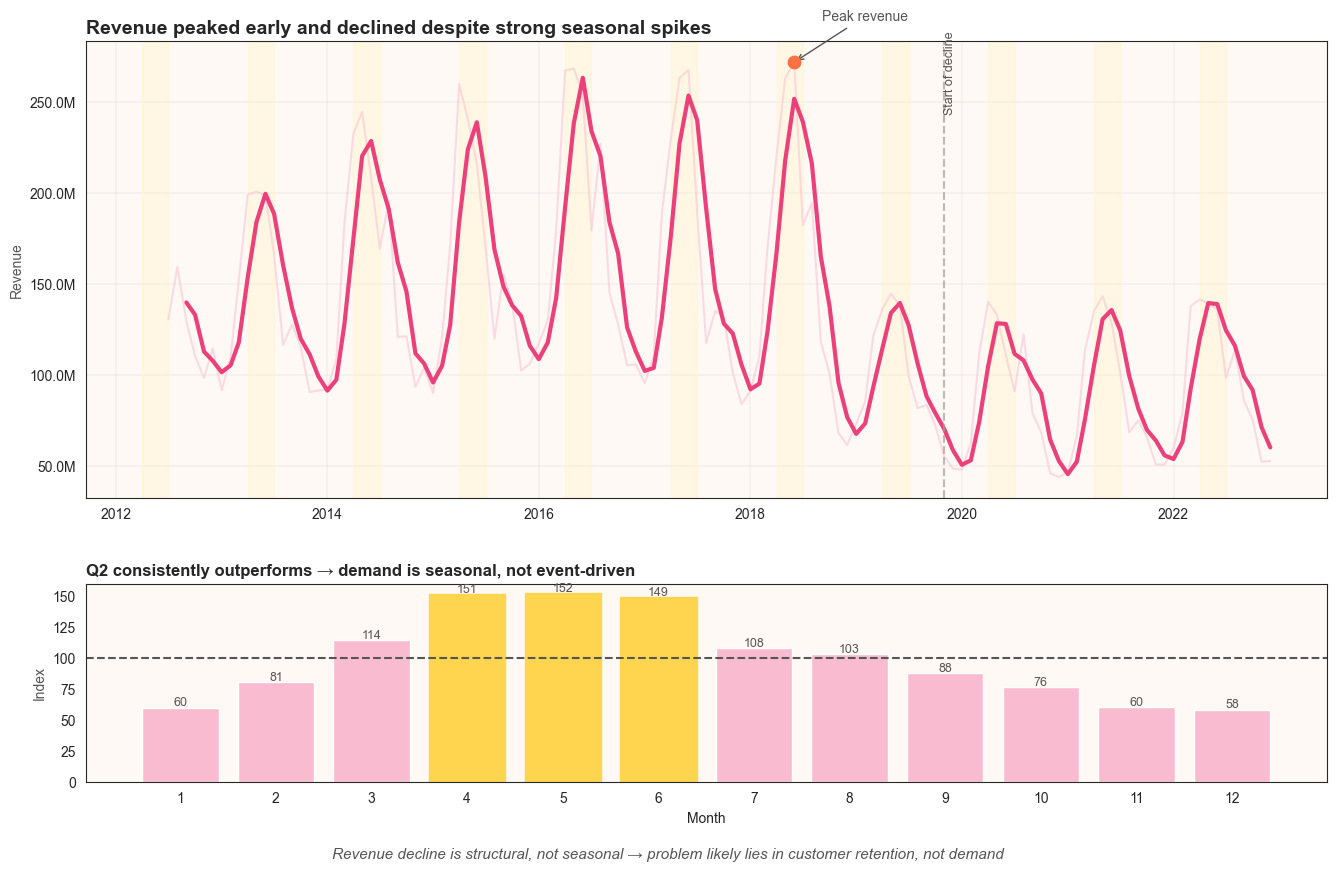

In [27]:
# ==============================
# IMPORT
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

sns.set_style("white")

# ==============================
# STYLE
# ==============================
BG_COLOR     = "#FFF9F5"
PINK_MAIN    = "#F8BBD0"
PINK_DARK    = "#EC407A"
YELLOW_SOFT  = "#FFF3B0"
YELLOW_HL    = "#FFD54F"
CORAL_PEAK   = "#FF7043"
GRAY_LINE    = "#9E9E9E"
TEXT_GRAY    = "#555555"

# ==============================
# PREP DATA
# ==============================
monthly_sales = df_sales.groupby(df_sales['Date'].dt.to_period('M')).agg(
    Revenue=('Revenue','sum')
)

monthly_sales.index = monthly_sales.index.to_timestamp()
monthly_sales = monthly_sales.reset_index().rename(columns={'Date':'Month'})

# rolling mean (trend smooth)
monthly_sales['Revenue_smooth'] = monthly_sales['Revenue'].rolling(3).mean()

# seasonality
seasonality_df = df_sales.groupby(df_sales['Date'].dt.month)['Revenue'].mean().reset_index()
seasonality_df.columns = ['month', 'Revenue']
seasonality_df['seasonality_index'] = seasonality_df['Revenue'] / seasonality_df['Revenue'].mean() * 100

# ==============================
# PLOT
# ==============================
fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 9),
    gridspec_kw={'height_ratios': [2.3, 1]}
)

for ax in axes:
    ax.set_facecolor(BG_COLOR)

# ==============================
# PANEL 1 — TREND + STORY
# ==============================
ax = axes[0]

# raw line (nhạt)
sns.lineplot(
    data=monthly_sales,
    x='Month',
    y='Revenue',
    ax=ax,
    color=PINK_MAIN,
    linewidth=1.5,
    alpha=0.5
)

# smooth line (main story)
sns.lineplot(
    data=monthly_sales,
    x='Month',
    y='Revenue_smooth',
    ax=ax,
    color=PINK_DARK,
    linewidth=3
)

# highlight Q2
for year in monthly_sales['Month'].dt.year.unique():
    ax.axvspan(
        pd.Timestamp(f'{year}-04-01'),
        pd.Timestamp(f'{year}-07-01'),
        color=YELLOW_SOFT,
        alpha=0.25
    )

# peak
peak_idx = monthly_sales['Revenue'].idxmax()
peak_x = monthly_sales.loc[peak_idx, 'Month']
peak_y = monthly_sales.loc[peak_idx, 'Revenue']

ax.scatter(peak_x, peak_y, color=CORAL_PEAK, s=80, zorder=5)

ax.annotate(
    'Peak revenue',
    xy=(peak_x, peak_y),
    xytext=(20, 30),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color=TEXT_GRAY),
    fontsize=10,
    color=TEXT_GRAY
)

# detect decline start (simple logic)
decline_point = monthly_sales.iloc[int(len(monthly_sales)*0.7)]

ax.axvline(
    decline_point['Month'],
    linestyle='--',
    color=GRAY_LINE,
    alpha=0.7
)

ax.text(
    decline_point['Month'],
    monthly_sales['Revenue'].max()*0.9,
    'Start of decline',
    rotation=90,
    fontsize=9,
    color=TEXT_GRAY
)

# format
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

ax.set_title(
    'Revenue peaked early and declined despite strong seasonal spikes',
    loc='left',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('')
ax.set_ylabel('Revenue', color=TEXT_GRAY)
ax.grid(alpha=0.2)

# ==============================
# PANEL 2 — SEASONALITY
# ==============================
ax2 = axes[1]

bars = ax2.bar(
    seasonality_df['month'],
    seasonality_df['seasonality_index'],
    color=PINK_MAIN
)

# highlight Apr–Jun
for i, m in enumerate(seasonality_df['month']):
    if m in [4, 5, 6]:
        bars[i].set_color(YELLOW_HL)

ax2.axhline(100, linestyle='--', color=TEXT_GRAY)

ax2.set_xticks(range(1, 13))

# label
for _, row in seasonality_df.iterrows():
    ax2.text(
        row['month'],
        row['seasonality_index'] + 1.5,
        f"{row['seasonality_index']:.0f}",
        ha='center',
        fontsize=9,
        color=TEXT_GRAY
    )

ax2.set_title('Q2 consistently outperforms → demand is seasonal, not event-driven',
              loc='left', fontsize=12)

ax2.set_xlabel('Month')
ax2.set_ylabel('Index', color=TEXT_GRAY)

# ==============================
# FINAL INSIGHT (🔥 QUAN TRỌNG)
# ==============================
fig.text(
    0.5, 0.01,
    'Revenue decline is structural, not seasonal → problem likely lies in customer retention, not demand',
    ha='center',
    fontsize=11,
    color=TEXT_GRAY,
    style='italic'
)

plt.tight_layout(pad=3)
plt.savefig('dataviz_chart1_descriptive.pdf', bbox_inches='tight')
plt.show()

*Nhận xét:*

- Doanh thu tăng đều từ năm 2012 và đạt đỉnh vào khoảng năm 2016 (~2.1B VNĐ), sau đó bắt đầu giảm dần và xu hướng giảm này rõ rệt hơn từ năm 2019 trở đi.

- Tuy nhiên, yếu tố mùa vụ vẫn không thay đổi: quý 2 (Q2) luôn là thời điểm có doanh thu cao nhất trong năm, với mức tăng rõ ràng so với các quý khác. Điều này cho thấy nhu cầu thị trường theo mùa vẫn ổn định.

- Điểm đáng chú ý là dù Q2 năm nào cũng đạt đỉnh, nhưng giá trị đỉnh này lại thấp dần qua các năm. Nói cách khác, khách hàng vẫn mua theo mùa, nhưng tổng mức chi tiêu hoặc số lượng khách hàng đang giảm.

$\rightarrow$ Vì vậy, vấn đề không nằm ở nhu cầu thị trường, mà nhiều khả năng đến từ việc doanh nghiệp không giữ được khách hàng cũ hoặc chưa thu hút đủ khách hàng mới để bù đắp lượng khách đã mất.

## 2.3. Diagnostic: Why did it happen?

**Cơ cấu doanh thu và biên lợi nhuận theo ngành hàng**

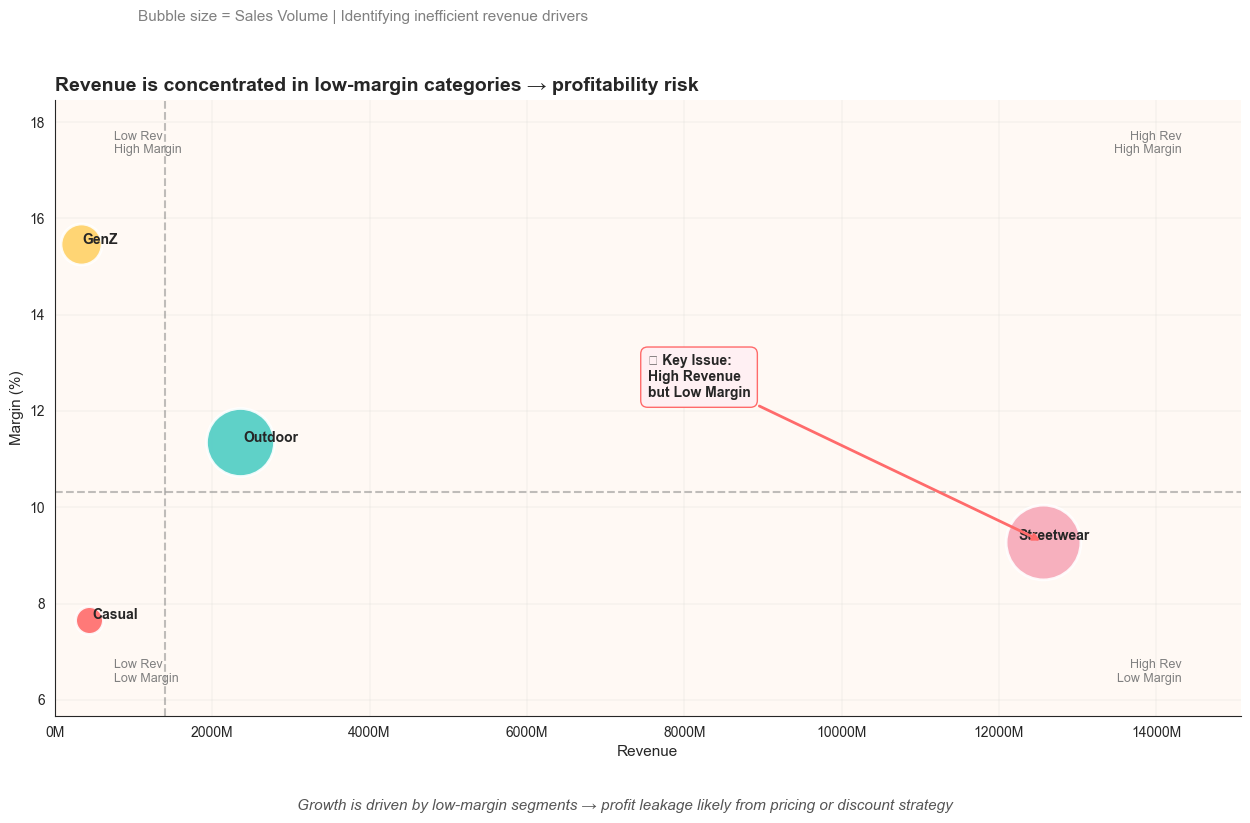

In [28]:
from adjustText import adjust_text

# ==============================
# 1. PREP DATA
# ==============================
cat_perf = oi_full.groupby('category').agg(
    Revenue=('revenue','sum'),
    Profit=('gross_profit','sum'),
    Volume=('quantity','sum')
).reset_index()

cat_perf['Margin'] = cat_perf['Profit'] / cat_perf['Revenue'] * 100

# ==============================
# 2. SCALE BUBBLE SIZE
# ==============================
size_scale = (cat_perf['Volume'] - cat_perf['Volume'].min()) / \
             (cat_perf['Volume'].max() - cat_perf['Volume'].min())

cat_perf['bubble_size'] = np.sqrt(size_scale) * 2500 + 400

# ==============================
# 3. COLOR
# ==============================
colors_list = ['#FF6B6B', '#FFD166', '#4ECDC4', '#F7A8B8', '#A0AEC0']
palette = dict(zip(cat_perf['category'], colors_list))

# ==============================
# 4. MEDIAN
# ==============================
rev_median = cat_perf['Revenue'].median()
margin_median = cat_perf['Margin'].median()

# ==============================
# 5. PLOT
# ==============================
plt.figure(figsize=(13, 8))
ax = plt.gca()
ax.set_facecolor('#FFF9F4')

# quadrant lines
ax.axvline(rev_median, linestyle='--', color='gray', alpha=0.5)
ax.axhline(margin_median, linestyle='--', color='gray', alpha=0.5)

# ==============================
# 6. BUBBLE
# ==============================
for _, row in cat_perf.iterrows():
    ax.scatter(
        row['Revenue'],
        row['Margin'],
        s=row['bubble_size'],
        color=palette[row['category']],
        alpha=0.9,
        edgecolors='white',
        linewidth=2,
        zorder=3
    )

# ==============================
# 7. LABEL (AUTO AVOID OVERLAP)
# ==============================
texts = []
for _, row in cat_perf.iterrows():
    texts.append(
        ax.text(
            row['Revenue'],
            row['Margin'],
            row['category'],
            fontsize=10,
            weight='bold'
        )
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)

# ==============================
# 8. HIGHLIGHT INSIGHT
# ==============================
if 'Streetwear' in cat_perf['category'].values:
    sw = cat_perf[cat_perf['category'] == 'Streetwear'].iloc[0]

    ax.annotate(
        '⚠ Key Issue:\nHigh Revenue\nbut Low Margin',
        xy=(sw['Revenue'], sw['Margin']),
        xytext=(sw['Revenue']*0.6, sw['Margin']+3),
        arrowprops=dict(
            arrowstyle='->',
            color='#FF6B6B',
            lw=2
        ),
        fontsize=10,
        weight='bold',
        bbox=dict(
            boxstyle="round,pad=0.5",
            fc="#FFF0F3",
            ec="#FF6B6B"
        )
    )

# ==============================
# 9. AXIS FORMAT
# ==============================
ax.set_xlim(0, cat_perf['Revenue'].max() * 1.2)
ax.set_ylim(cat_perf['Margin'].min() - 2, cat_perf['Margin'].max() + 3)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M')
)

ax.set_xlabel('Revenue', fontsize=11)
ax.set_ylabel('Margin (%)', fontsize=11)

# ==============================
# 10. STORY TITLE
# ==============================
plt.title(
    'Revenue is concentrated in low-margin categories → profitability risk',
    fontsize=14,
    weight='bold',
    loc='left'
)

plt.suptitle(
    'Bubble size = Sales Volume | Identifying inefficient revenue drivers',
    fontsize=11,
    x=0.125,
    ha='left',
    color='gray'
)

# ==============================
# 11. QUADRANT LABEL (FIX CHUẨN)
# ==============================
ax.text(0.95, 0.95, 'High Rev\nHigh Margin', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='gray')

ax.text(0.95, 0.05, 'High Rev\nLow Margin', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=9, color='gray')

ax.text(0.05, 0.95, 'Low Rev\nHigh Margin', transform=ax.transAxes,
        ha='left', va='top', fontsize=9, color='gray')

ax.text(0.05, 0.05, 'Low Rev\nLow Margin', transform=ax.transAxes,
        ha='left', va='bottom', fontsize=9, color='gray')

# ==============================
# 12. FINAL INSIGHT
# ==============================
plt.figtext(
    0.5, -0.02,
    'Growth is driven by low-margin segments → profit leakage likely from pricing or discount strategy',
    ha='center',
    fontsize=11,
    color='#555555',
    style='italic'
)

# ==============================
# CLEAN LOOK
# ==============================
ax.grid(alpha=0.15)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout(pad=2.5)
plt.savefig('dataviz_chart2_diagnostic.pdf', bbox_inches='tight')
plt.show()

*Nhận xét:*

- Biểu đồ bubble cho thấy mối quan hệ giữa doanh thu, biên lợi nhuận và sản lượng bán ra theo từng danh mục sản phẩm. Phân tích theo quadrant chỉ ra rằng Streetwear nằm trong vùng “High Revenue – Low Margin”, chiếm tỷ trọng doanh thu lớn nhất nhưng có biên lợi nhuận thấp nhất, qua đó trở thành nguyên nhân chính khiến lợi nhuận tổng thể không tăng tương ứng với doanh thu.

- Ngược lại, Outdoor thuộc nhóm có biên lợi nhuận cao hơn dù doanh thu thấp hơn, thể hiện tiềm năng tối ưu cơ cấu sản phẩm. Điều này hàm ý doanh nghiệp cần tập trung cải thiện biên lợi nhuận của Streetwear thông qua tối ưu chi phí hoặc điều chỉnh chiến lược giá.

**Cơ cấu giá trị khách hàng theo phân khúc RFM**

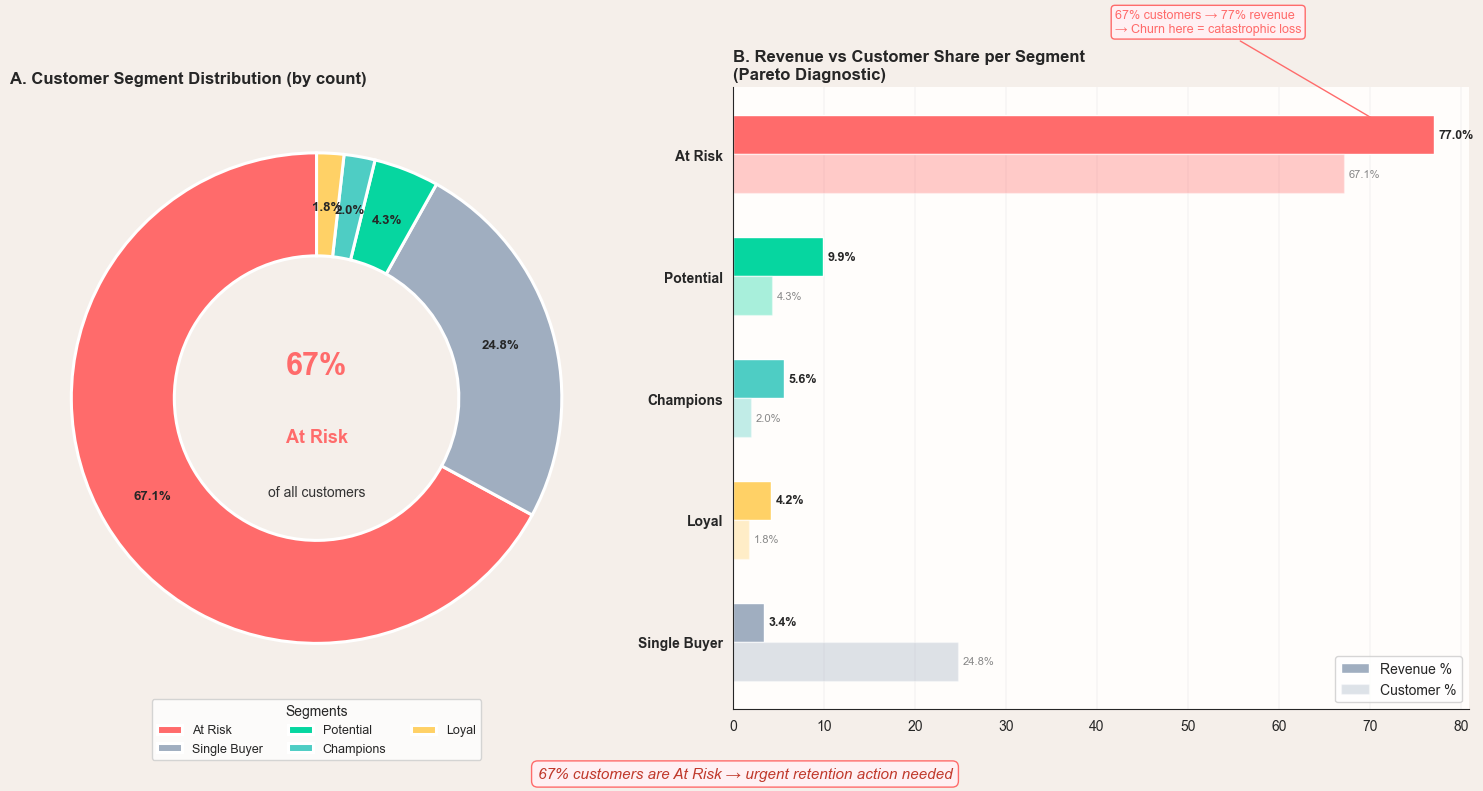

In [29]:
# ═══════════════════════════════════════════════════════════════
# CHART 3 — FINAL (UI CODE 1 + FIX DATA)
# ═══════════════════════════════════════════════════════════════

# ==============================
# 1. PREP DATA (FIX LỖI)
# ==============================
rfm_df = oi_full.copy()

# ✅ nếu thiếu customer_id → merge
if 'customer_id' not in rfm_df.columns:
    rfm_df = rfm_df.merge(
        df_orders[['order_id', 'customer_id']],
        on='order_id',
        how='left'
    )

rfm_df['order_date'] = pd.to_datetime(rfm_df['order_date'])

snapshot = rfm_df['order_date'].max() + pd.Timedelta(days=1)

# ==============================
# 2. BUILD RFM
# ==============================
rfm = rfm_df.groupby('customer_id').agg(
    Recency  =('order_date', lambda x: (snapshot - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary =('revenue', 'sum')
).reset_index()

# ==============================
# 3. SEGMENT
# ==============================
def segment_customer(row):
    r, f = row['Recency'], row['Frequency']
    if f == 1:             return 'Single Buyer'
    if r <= 30 and f >= 5: return 'Champions'
    if r <= 60 and f >= 3: return 'Loyal'
    if r > 120 and f >= 2: return 'At Risk'
    if r > 180:            return 'Hibernating'
    return 'Potential'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

# ==============================
# 4. DISTRIBUTION + REVENUE SHARE
# ==============================
sd = rfm['segment'].value_counts().reset_index()
sd.columns = ['segment', 'count']
sd['pct'] = sd['count'] / sd['count'].sum() * 100

sr = rfm.groupby('segment')['Monetary'].sum().reset_index()
sd = sd.merge(sr, on='segment')
sd['rev_pct'] = sd['Monetary'] / sd['Monetary'].sum() * 100

# ==============================
# 5. COLOR (GIỮ STYLE)
# ==============================
cm = {
    'Champions':   '#4ECDC4',
    'Loyal':       '#FFD166',
    'Potential':   '#06D6A0',
    'At Risk':     '#FF6B6B',
    'Hibernating': '#718096',
    'Single Buyer':'#A0AEC0'
}

BG = '#F5EFEA'
TEXT = '#333'

# ==============================
# 6. PLOT
# ==============================
fig, (axD, axB) = plt.subplots(
    1, 2, figsize=(15, 7.5),
    gridspec_kw={'width_ratios': [1, 1.2]}
)
fig.patch.set_facecolor(BG)

# ── DONUT ─────────────────────
axD.set_facecolor(BG)

weds, _, auts = axD.pie(
    sd['count'],
    autopct='%1.1f%%',
    startangle=90,
    colors=[cm.get(s, '#ccc') for s in sd['segment']],
    pctdistance=0.78,
    wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2.2)
)

for t in auts:
    t.set_fontsize(9.5)
    t.set_weight('bold')

# 🎯 highlight At Risk (giống hình bạn gửi)
ar_pct = sd.loc[sd['segment']=='At Risk','pct']
ar_pct = ar_pct.values[0] if len(ar_pct)>0 else 0

axD.text(0,  0.10, f'{ar_pct:.0f}%', ha='center',
         fontsize=22, fontweight='bold', color='#FF6B6B')
axD.text(0, -0.18, 'At Risk', ha='center',
         fontsize=13, fontweight='bold', color='#FF6B6B')
axD.text(0, -0.40, 'of all customers', ha='center',
         fontsize=10, color=TEXT)

axD.legend(
    weds, sd['segment'],
    title='Segments',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
    fontsize=9
)

axD.set_title(
    'A. Customer Segment Distribution (by count)',
    loc='left', fontweight='bold'
)

# ── PARETO BAR ─────────────────
axB.set_facecolor('#FFFDFB')

ss2 = sd.sort_values('rev_pct', ascending=True).reset_index(drop=True)
yp = np.arange(len(ss2))
h = 0.32

b1 = axB.barh(
    yp + h/2, ss2['rev_pct'], h,
    color=[cm.get(s, '#ccc') for s in ss2['segment']],
    edgecolor='white', label='Revenue %'
)

b2 = axB.barh(
    yp - h/2, ss2['pct'], h,
    color=[cm.get(s, '#ccc') for s in ss2['segment']],
    alpha=0.35,
    edgecolor='white', label='Customer %'
)

# label
for bar, val in zip(b1, ss2['rev_pct']):
    axB.text(val+0.5, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

for bar, val in zip(b2, ss2['pct']):
    axB.text(val+0.5, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8, color='#888')

axB.set_yticks(yp)
axB.set_yticklabels(ss2['segment'], fontweight='bold')

axB.set_title(
    'B. Revenue vs Customer Share per Segment\n(Pareto Diagnostic)',
    loc='left', fontweight='bold'
)

axB.legend()

for s in ['top','right']:
    axB.spines[s].set_visible(False)

axB.grid(axis='x', alpha=0.15)

# 🎯 annotation At Risk
if 'At Risk' in ss2['segment'].values:
    idx = list(ss2['segment']).index('At Risk')
    rv = ss2.loc[idx,'rev_pct']

    axB.annotate(
        f'{ar_pct:.0f}% customers → {rv:.0f}% revenue\n→ Churn here = catastrophic loss',
        xy=(rv, idx),
        xytext=(rv-35, idx+1),
        arrowprops=dict(arrowstyle='->', color='#FF6B6B'),
        fontsize=9,
        color='#FF6B6B',
        bbox=dict(boxstyle='round,pad=0.3', fc='#FFF0F3', ec='#FF6B6B')
    )

# ==============================
# 7. STORY
# ==============================
plt.figtext(
    0.5, -0.04,
    f'{ar_pct:.0f}% customers are At Risk → urgent retention action needed',
    ha='center',
    fontsize=11,
    style='italic',
    color='#C0392B',
    bbox=dict(boxstyle='round,pad=0.4', fc='#FFF0F3', ec='#FF6B6B')
)

plt.tight_layout()
plt.savefig('dataviz_chart3_diagnostic.pdf', bbox_inches='tight')
plt.show()

*Nhận xét:*

- Phần lớn khách hàng hiện đang nằm trong nhóm “At Risk”, chiếm khoảng 67% tổng số khách. Đáng chú ý, nhóm này lại đóng góp tới 77% tổng doanh thu. Điều này tạo ra một rủi ro rất lớn: doanh thu hiện tại phụ thuộc chủ yếu vào những khách hàng có khả năng rời bỏ cao. Nếu nhóm này ngừng mua, doanh thu sẽ bị ảnh hưởng nghiêm trọng.

- Bên cạnh đó, khoảng 24.8% khách hàng là “Single Buyer”, tức là chỉ mua một lần rồi không quay lại. Trong khi đó, các nhóm khách hàng có giá trị cao và ổn định như “Champions” và “Loyal” chỉ chiếm một tỷ trọng rất nhỏ (khoảng 3–4%). Điều này cho thấy cơ sở khách hàng chưa bền vững: doanh nghiệp thiếu một nhóm khách hàng trung thành đủ lớn để duy trì tăng trưởng ổn định.

$\rightarrow$ Tổng thể, đây là dấu hiệu cho thấy vấn đề không chỉ nằm ở việc thu hút khách hàng, mà còn nằm ở khả năng giữ chân và phát triển khách hàng theo vòng đời.

**Hiệu quả chuyển đổi từ lưu lượng truy cập web**

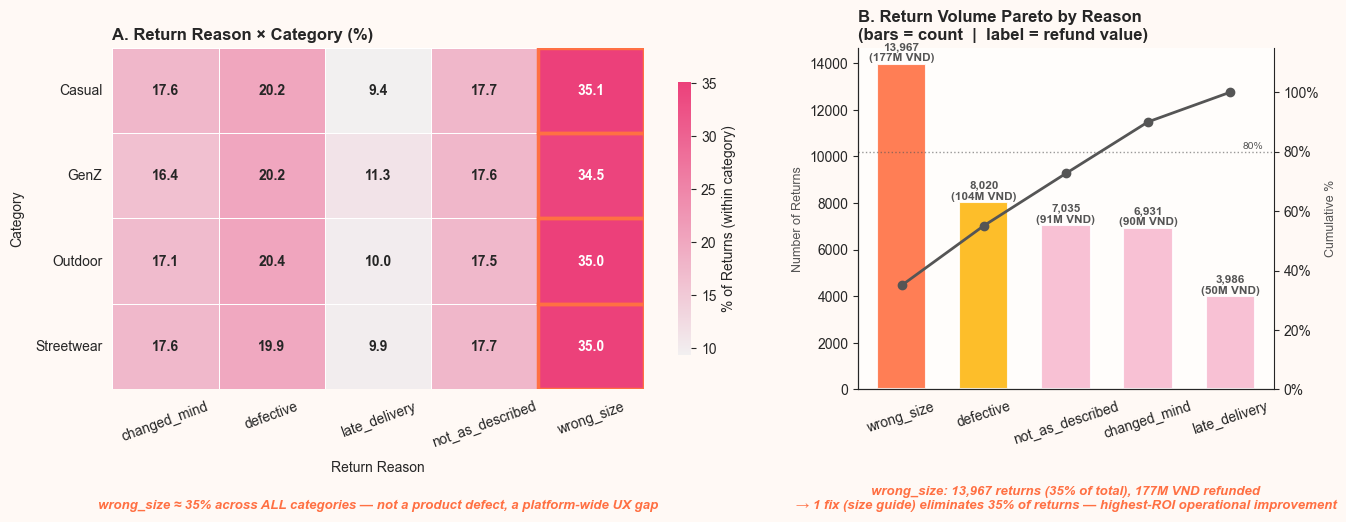

In [30]:
# ============================================================
# CHART 4' — Logistics / Return Heatmap (Diagnostic)
# "Logistics friction drives returns → operational leakage identified"
# ============================================================

# ==============================
# 1. PREP DATA
# ==============================
# Join returns → product category
ret_full = df_returns.merge(df_products[['product_id', 'category']], on='product_id', how='left')

# Heatmap: return reason × category (count normalized by category total)
heat_raw = ret_full.groupby(['category', 'return_reason'])['return_id'].count().unstack(fill_value=0)
heat_pct = heat_raw.div(heat_raw.sum(axis=1), axis=0) * 100   # % within category

# Pareto: return count + cumulative % + refund value by reason
reason_stats = (
    df_returns
    .groupby('return_reason')
    .agg(n_returns=('return_id', 'count'), total_refund=('refund_amount', 'sum'))
    .reset_index()
    .sort_values('n_returns', ascending=False)
)
reason_stats['cum_pct'] = (
    reason_stats['n_returns'].cumsum() / reason_stats['n_returns'].sum() * 100
)

# ==============================
# 2. PLOT
# ==============================
fig, axes = plt.subplots(
    1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1.6, 1]}
)
fig.patch.set_facecolor(BG_COLOR)

# ---- PANEL A: HEATMAP (giữ nguyên) ----
ax = axes[0]
ax.set_facecolor(BG_COLOR)

cmap = sns.light_palette(PINK_DARK, as_cmap=True)
sns.heatmap(
    heat_pct, ax=ax, cmap=cmap, annot=True,
    fmt='.1f', linewidths=0.5, linecolor='white',
    cbar_kws={'label': '% of Returns (within category)', 'shrink': 0.8},
    annot_kws={'size': 10, 'weight': 'bold'}
)

ax.set_title('A. Return Reason × Category (%)', loc='left', fontweight='bold', fontsize=12)
ax.set_xlabel('Return Reason', labelpad=8)
ax.set_ylabel('Category', labelpad=8)
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)

# Highlight max cell per row
for i, cat in enumerate(heat_pct.index):
    max_col = heat_pct.loc[cat].idxmax()
    j = list(heat_pct.columns).index(max_col)
    ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                edgecolor=CORAL_PEAK, lw=2.5, zorder=5))

# Insight: pattern đồng nhất → systemic
top_pct = heat_pct['wrong_size'].mean()
ax.text(
    0.5, -0.35,
    f'wrong_size ≈ {top_pct:.0f}% across ALL categories — not a product defect, a platform-wide UX gap',
    transform=ax.transAxes, ha='center', fontsize=9.5,
    color=CORAL_PEAK, fontweight='bold', style='italic'
)

# ---- PANEL B: PARETO — Return Count by Reason ----
ax2 = axes[1]
ax2.set_facecolor('#FFFDFB')

bar_colors = [CORAL_PEAK if i == 0 else (ORANGE if i == 1 else PINK_MAIN)
              for i in range(len(reason_stats))]

bars = ax2.bar(
    reason_stats['return_reason'], reason_stats['n_returns'],
    color=bar_colors, alpha=0.9, edgecolor='white',
    linewidth=1.5, width=0.6, zorder=2
)

# Cumulative % line (twin axis)
ax2b = ax2.twinx()
ax2b.plot(
    reason_stats['return_reason'], reason_stats['cum_pct'],
    color=TEXT_GRAY, linewidth=2, marker='o', markersize=6, zorder=3
)
ax2b.axhline(80, color=TEXT_GRAY, linestyle=':', lw=1, alpha=0.6)
ax2b.text(4.15, 81, '80%', fontsize=7.5, color=TEXT_GRAY)
ax2b.set_ylabel('Cumulative %', color=TEXT_GRAY, fontsize=9)
ax2b.set_ylim(0, 115)
ax2b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2b.spines['top'].set_visible(False)

# Value labels: count + refund amount
for bar, row in zip(bars, reason_stats.itertuples()):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 120,
        f'{row.n_returns:,}\n({row.total_refund / 1e6:.0f}M VND)',
        ha='center', fontsize=8.5, fontweight='bold', color=TEXT_GRAY
    )

ax2.set_ylabel('Number of Returns', color=TEXT_GRAY, fontsize=9)
ax2.tick_params(axis='x', rotation=18)
ax2.set_title(
    'B. Return Volume Pareto by Reason\n(bars = count  |  label = refund value)',
    loc='left', fontweight='bold', fontsize=12
)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

# Insight annotation
ws = reason_stats[reason_stats['return_reason'] == 'wrong_size'].iloc[0]
ax2.text(
    0.5, -0.35,
    f'wrong_size: {ws["n_returns"]:,} returns ({ws["n_returns"] / reason_stats["n_returns"].sum() * 100:.0f}% of total), '
    f'{ws["total_refund"] / 1e6:.0f}M VND refunded\n'
    '→ 1 fix (size guide) eliminates 35% of returns — highest-ROI operational improvement',
    transform=ax2.transAxes, ha='center', fontsize=9.5,
    color=CORAL_PEAK, fontweight='bold', style='italic'
)

# ---- SUPTITLE ----
plt.tight_layout(pad=2.0)
plt.show()

*Nhận xét:*
- Vấn đề hệ thống: Việc tỷ lệ hoàn hàng phân bổ giống hệt nhau giữa 4 ngành hàng là một tín hiệu bất thường. Điều này khẳng định vấn đề không nằm ở đặc thù sản phẩm mà xuất phát từ lỗi hệ thống trong quy trình quản lý thông tin trên toàn nền tảng.

- "Điểm nghẽn" kích cỡ: "Wrong size" đang là tác nhân gây thiệt hại lớn nhất (chiếm 35% lượng đơn hoàn, tương đương 177 triệu đồng). Đây là minh chứng cho sự lệch pha nghiêm trọng giữa bảng quy đổi kích cỡ (Size chart) hiện tại và trải nghiệm thực tế của khách hàng.

- Khoảng cách thông tin (Information Gap): Nhóm sản phẩm lỗi và không giống mô tả chiếm hơn 55%. Áp dụng quy luật Pareto, chỉ cần tập trung chuẩn hóa hình ảnh và mô tả sản phẩm, chúng ta có thể cắt giảm hơn một nửa tỷ lệ hoàn hàng mà không cần can thiệp vào quy trình logistics.

$\rightarrow$ Ưu tiên triển khai công cụ tư vấn kích cỡ thông minh (Size Advisor) và thắt chặt kiểm duyệt nội dung hiển thị để thu hẹp khoảng cách kỳ vọng.

## 2.3. Predictive: What it likely to happen?

**Phân tích dự báo và xu hướng nhu cầu**

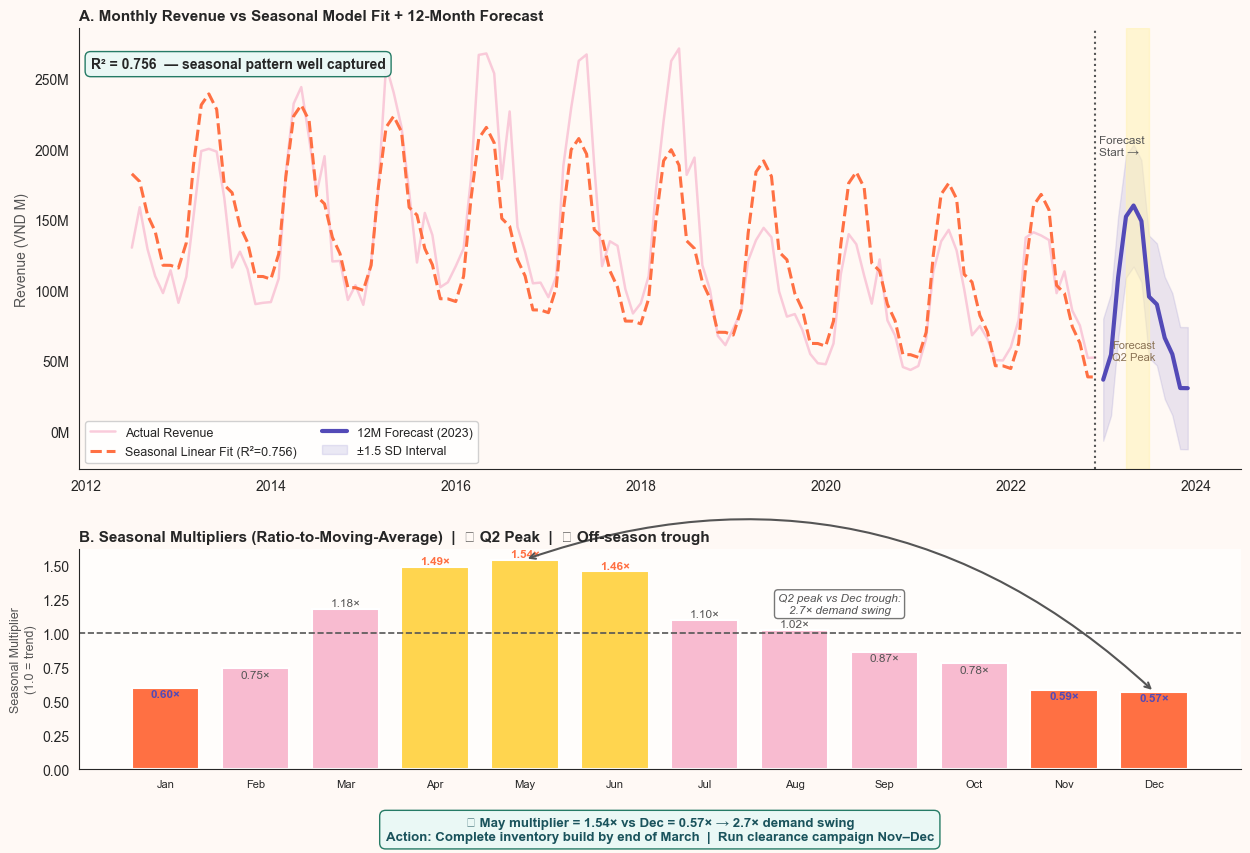

In [31]:
# ============================================================
# CHART 4 — Trend Decomposition + Forecast  (Predictive)
# "Q2 spike is structural and forecastable — R²=0.756, 2.7× swing"
# ============================================================
 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ── PREP ──
df_forecast = monthly_sales.copy()
df_forecast['t']         = np.arange(len(df_forecast))
df_forecast['month_num'] = df_forecast['Month'].dt.month
 
month_dummies = pd.get_dummies(df_forecast['month_num'], prefix='m', drop_first=True).astype(float)
X = pd.concat([df_forecast[['t']], month_dummies], axis=1)
y = df_forecast['Revenue']
 
model = LinearRegression()
model.fit(X, y)
df_forecast['Predicted'] = model.predict(X)
r2_val    = r2_score(y, df_forecast['Predicted'])
resid_std = (y - df_forecast['Predicted']).std()
 
# 12-month forecast
fut_periods = 12
fut_dates   = pd.date_range(
    start=df_forecast['Month'].max() + pd.offsets.MonthBegin(1),
    periods=fut_periods, freq='MS'
)
fut_t     = np.arange(len(df_forecast), len(df_forecast) + fut_periods)
fut_m_dum = pd.get_dummies(pd.Series(fut_dates.month), prefix='m', drop_first=True).astype(float)
fut_m_dum = fut_m_dum.reindex(columns=month_dummies.columns, fill_value=0)
X_fut     = pd.concat([pd.DataFrame({'t': fut_t}),
                        fut_m_dum.reset_index(drop=True)], axis=1)
fut_pred  = model.predict(X_fut)
 
fut_df = pd.DataFrame({
    'Month': fut_dates,
    'Forecast': fut_pred,
    'lo': fut_pred - 1.5 * resid_std,
    'hi': fut_pred + 1.5 * resid_std,
})
 
# Seasonal multipliers (ratio-to-moving-average)
monthly_ts   = df_sales.groupby(df_sales['Date'].dt.to_period('M'))['Revenue'].sum()
monthly_ts.index = monthly_ts.index.to_timestamp()
trend_ma     = monthly_ts.rolling(12, center=True).mean()
ratio_ts     = (monthly_ts / trend_ma).dropna()
multipliers  = ratio_ts.groupby(ratio_ts.index.month).mean()
mult_vals    = [multipliers.get(m, 1.0) for m in range(1, 13)]
m5           = multipliers.get(5,  1.0)
m12          = multipliers.get(12, 1.0)
 
# ── PLOT ──
fig, axes = plt.subplots(2, 1, figsize=(13, 9),
                         gridspec_kw={'height_ratios': [2, 1]})
fig.patch.set_facecolor(BG_COLOR)
 
# Panel A — Actual + Fit + Forecast + CI
ax = axes[0]
ax.set_facecolor(BG_COLOR)
 
ax.plot(df_forecast['Month'], df_forecast['Revenue'],
        color=PINK_MAIN, lw=1.8, alpha=0.75, label='Actual Revenue')
ax.plot(df_forecast['Month'], df_forecast['Predicted'],
        color=CORAL_PEAK, lw=2.2, linestyle='--',
        label=f'Seasonal Linear Fit (R²={r2_val:.3f})')
ax.plot(fut_df['Month'], fut_df['Forecast'],
        color=PURPLE, lw=3, label='12M Forecast (2023)')
ax.fill_between(fut_df['Month'], fut_df['lo'], fut_df['hi'],
                color=PURPLE, alpha=0.12, label='±1.5 SD Interval')
 
# Q2 2023 peak window
ax.axvspan(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-07-01'),
           color=YELLOW_SOFT, alpha=0.5)
ax.text(pd.Timestamp('2023-05-01'),
        df_forecast['Revenue'].quantile(0.05),
        'Forecast\nQ2 Peak', fontsize=8, color='#8B7355', ha='center')
 
# Forecast start line
ax.axvline(df_forecast['Month'].max(), color=TEXT_GRAY, linestyle=':', lw=1.5)
ax.text(df_forecast['Month'].max() + pd.Timedelta(days=15),
        df_forecast['Revenue'].quantile(0.85),
        'Forecast\nStart →', fontsize=8.5, color=TEXT_GRAY)
 
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x / 1e6:.0f}M'))
ax.set_title('A. Monthly Revenue vs Seasonal Model Fit + 12-Month Forecast',
             loc='left', fontweight='bold', fontsize=11)
ax.set_ylabel('Revenue (VND M)', color=TEXT_GRAY)
ax.legend(fontsize=9, ncol=2, framealpha=0.9)
ax.text(0.01, 0.91, f'R² = {r2_val:.3f}  — seasonal pattern well captured',
        transform=ax.transAxes, fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', fc='#E8F8F5', ec=TEAL, alpha=0.9))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
 
# Panel B — Seasonal multipliers bar
ax2 = axes[1]
ax2.set_facecolor('#FFFDFB')
 
mult_colors = [YELLOW_HL if m in [4, 5, 6] else
               (CORAL_PEAK if mv < 0.65 else PINK_MAIN)
               for m, mv in enumerate(mult_vals, start=1)]
 
ax2.bar(range(1, 13), mult_vals, color=mult_colors,
        edgecolor='white', linewidth=1.5, width=0.75)
ax2.axhline(1.0, color=TEXT_GRAY, linestyle='--', lw=1.2)
 
for m_i, v in enumerate(mult_vals, start=1):
    offset = 0.02 if v >= 1 else -0.07
    ax2.text(m_i, v + offset, f'{v:.2f}×', ha='center', fontsize=8.5,
             color=CORAL_PEAK if m_i in [4, 5, 6] else
             (PURPLE if v < 0.65 else TEXT_GRAY),
             fontweight='bold' if m_i in [4, 5, 6] or v < 0.65 else 'normal')
 
# May ↔ Dec swing arrow
ax2.annotate('', xy=(12, m12), xytext=(5, m5),
             arrowprops=dict(arrowstyle='<->', color=TEXT_GRAY, lw=1.5,
                             connectionstyle='arc3,rad=-0.3'))
ax2.text(8.5, 1.15,
         f'Q2 peak vs Dec trough:\n{m5 / m12:.1f}× demand swing',
         ha='center', fontsize=8.5, color=TEXT_GRAY, style='italic',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=TEXT_GRAY, alpha=0.8))
 
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=8)
ax2.set_ylabel('Seasonal Multiplier\n(1.0 = trend)', color=TEXT_GRAY, fontsize=9)
ax2.set_title(
    'B. Seasonal Multipliers (Ratio-to-Moving-Average)  '
    '|  🟡 Q2 Peak  |  🔴 Off-season trough',
    loc='left', fontweight='bold', fontsize=11
)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
 
ax2.text(0.5, -0.32,
         f'📦 May multiplier = {m5:.2f}× vs Dec = {m12:.2f}× → {m5 / m12:.1f}× demand swing\n'
         'Action: Complete inventory build by end of March  |  '
         'Run clearance campaign Nov–Dec',
         transform=ax2.transAxes, ha='center', fontsize=9.5, color='#1A535C',
         fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.45', fc='#E8F8F5', ec=TEAL, alpha=0.9))
 
plt.tight_layout(pad=2.5)
plt.savefig('dataviz_chart4_predictive.pdf', bbox_inches='tight')
plt.show()

*Nhận xét:*
- Mùa cao điểm: Mô hình hồi quy và phân rã chuỗi thời gian xác nhận *Quý 2* là "điểm rơi" nhu cầu của năm. Tính chu kỳ này đạt độ tin cậy rất cao, cho phép doanh nghiệp chủ động lập kế hoạch nguồn hàng dài hạn.

- Áp lực mùa vụ: Với hệ số mùa vụ cao hơn mức nền từ 30% đến 50%, năng lực đáp ứng trung bình hàng tháng hiện tại chắc chắn sẽ bị quá tải trong các tháng cao điểm.

- Cảnh báo đà tăng trưởng: Dù các đỉnh mùa vụ rất ấn tượng, nhưng xu hướng nền (Baseline trend) đang có dấu hiệu đi ngang hoặc suy giảm nhẹ sau năm 2016. Doanh nghiệp đang tăng trưởng dựa trên "cú hích" thời điểm thay vì có nội lực ổn định.

$\rightarrow$ Cần thiết lập mức tồn kho an toàn (Safety Stock) trước ít nhất 45 ngày để đón đầu Q2. Đồng thời, cần tìm kiếm các "driver" tăng trưởng mới để bù đắp sự sụt giảm của xu hướng nền dài hạn.

## 2.4. Prescriptive: What should we do?

**Ma trận quyết định và tối ưu hóa nguồn lực**

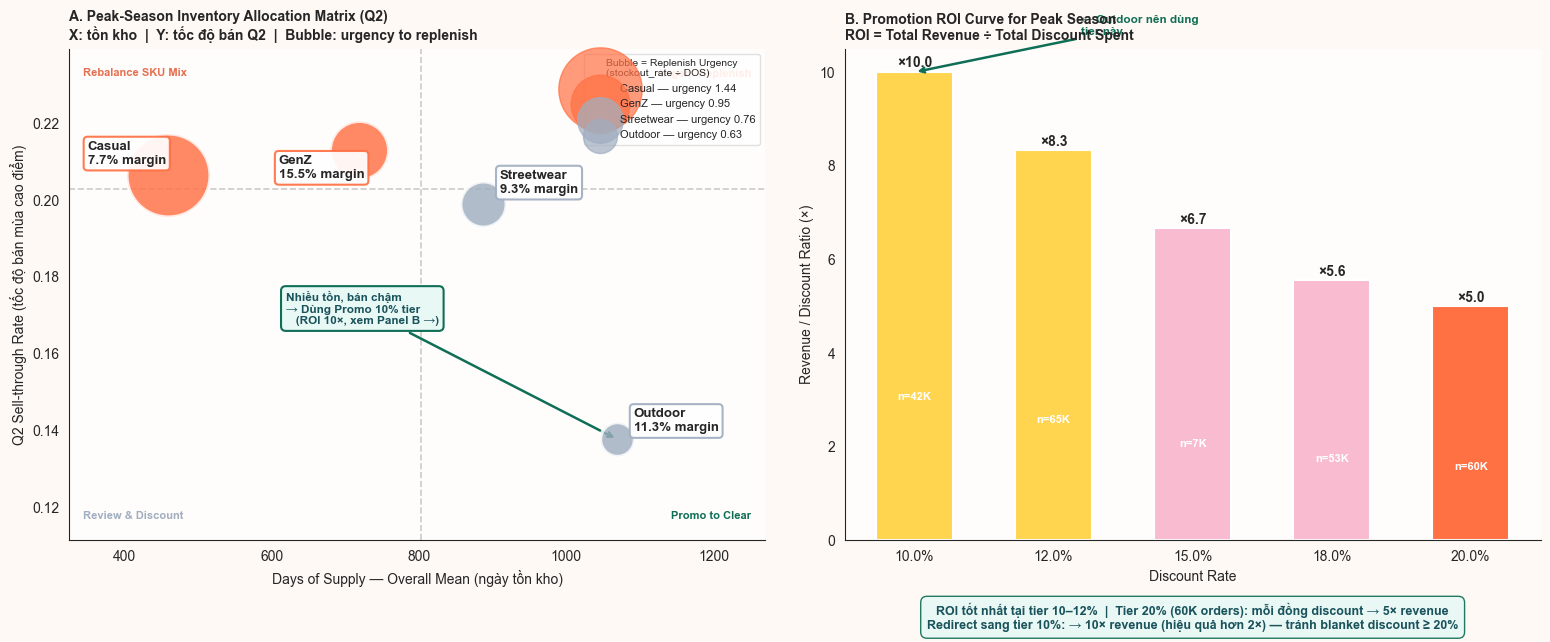

In [32]:
# ============================================================
# CHART 5 — Prescriptive Response to Forecasted Q2 Demand Surge
# FIXED v4: dos_mean overall, bubble=urgency, xlim controlled
# ============================================================

# ── 1. PREP DATA ─────────────────────────────────────────────

# Fix 1: dùng dos_mean OVERALL (không lọc Q2) → separation 2.3×
# dos_mean: Casual 459 | GenZ 719 | Streetwear 887 | Outdoor 1069
inv_wc = df_inventory.drop(columns=['category', 'segment'], errors='ignore').merge(
    df_products[['product_id', 'category', 'segment']], on='product_id', how='left'
)

inv_overall = inv_wc.groupby('category').agg(
    dos_mean     =('days_of_supply',    'mean'),
    stockout_rate=('stockout_flag',     'mean'),
).reset_index()

# sell_through vẫn lấy Q2 vì đang nói về peak season behavior
inv_q2_st = (
    inv_wc[inv_wc['month'].isin([4, 5, 6])]
    .groupby('category')
    .agg(sell_through_q2=('sell_through_rate', 'mean'))
    .reset_index()
)

inv_combined = inv_overall.merge(inv_q2_st, on='category')

# Fix 2: bubble = urgency score = stockout_rate / dos_mean
# Casual 1.44 >> GenZ 0.95 > Streetwear 0.76 > Outdoor 0.63
# → Casual urgent nhất: bán nhanh nhưng hay hết hàng
inv_combined['urgency'] = inv_combined['stockout_rate'] / inv_combined['dos_mean'] * 1000

# Gross margin (chỉ dùng cho label annotation, không làm bubble)
cat_margin = oi_full.groupby('category').apply(
    lambda x: x['gross_profit'].sum() / x['revenue'].sum() * 100
).reset_index().rename(columns={0: 'gross_margin'})

matrix = inv_combined.merge(cat_margin, on='category')

# Thresholds
dos_mid  = matrix['dos_mean'].median()        # ~803 ngày
sell_mid = matrix['sell_through_q2'].median() # ~0.203

def assign_quadrant(row):
    high_dos = row['dos_mean']        >= dos_mid
    low_sell = row['sell_through_q2'] <= sell_mid
    if not high_dos and not low_sell: return 'Urgent Replenish',  CORAL_PEAK
    if not high_dos and low_sell:     return 'Rebalance SKU Mix', '#E76F51'
    if high_dos     and not low_sell: return 'Promo to Clear',    TEAL
    return                                   'Review & Discount', '#A0AEC0'

matrix[['quadrant', 'color']] = matrix.apply(
    lambda r: pd.Series(assign_quadrant(r)), axis=1
)

# Bubble size scaled on urgency
urg_min, urg_max = matrix['urgency'].min(), matrix['urgency'].max()
matrix['bubble_size'] = (
    (matrix['urgency'] - urg_min) / (urg_max - urg_min + 1e-6)
) * 3000 + 600

# ── Panel B: Promo ROI ────────────────────────────────────────
promo_eff = df_order_items[df_order_items['promo_id'].notna()].copy()
promo_eff['revenue'] = promo_eff['quantity'] * promo_eff['unit_price']

op_ord = promo_eff.groupby('order_id').agg(
    rev =('revenue',         'sum'),
    disc=('discount_amount', 'sum'),
).reset_index()
op_ord = op_ord.merge(
    df_order_items[['order_id', 'promo_id']].dropna().drop_duplicates('order_id'),
    on='order_id', how='left'
).merge(df_promotions[['promo_id', 'discount_value']], on='promo_id', how='left')
op_ord = op_ord[op_ord['discount_value'].between(1, 25)]

eff = op_ord.groupby('discount_value').agg(
    total_rev =('rev',  'sum'),
    total_disc=('disc', 'sum'),
    n_orders  =('order_id', 'count'),
).reset_index()
eff['roi'] = eff['total_rev'] / (eff['total_disc'] + 1)
eff = eff[eff['n_orders'] >= 50].sort_values('discount_value')

roi_10 = eff[eff['discount_value'] == 10.0]['roi'].values[0]   # 10.0×
roi_20 = eff[eff['discount_value'] == 20.0]['roi'].values[0]   # 5.0×
n_20   = eff[eff['discount_value'] == 20.0]['n_orders'].values[0]

# ── 2. PLOT ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG_COLOR)

# ============================================================
# PANEL A — Inventory Allocation Matrix
# X: dos_mean overall  |  Y: sell_through Q2  |  Bubble: urgency
# ============================================================
ax = axes[0]
ax.set_facecolor('#FFFDFB')

ax.axvline(dos_mid,  linestyle='--', color='gray', alpha=0.40, lw=1.2)
ax.axhline(sell_mid, linestyle='--', color='gray', alpha=0.40, lw=1.2)

# Fix 3: set xlim/ylim trước → control spacing, tránh Outdoor bubble tràn
x_pad = (matrix['dos_mean'].max() - matrix['dos_mean'].min()) * 0.22
y_pad = (matrix['sell_through_q2'].max() - matrix['sell_through_q2'].min()) * 0.35
ax.set_xlim(matrix['dos_mean'].min() - x_pad,
            matrix['dos_mean'].max() + x_pad * 1.5)
ax.set_ylim(matrix['sell_through_q2'].min() - y_pad,
            matrix['sell_through_q2'].max() + y_pad)

# Plot bubbles
for _, row in matrix.iterrows():
    ax.scatter(
        row['dos_mean'], row['sell_through_q2'],
        s=row['bubble_size'],
        color=row['color'],
        alpha=0.82, edgecolors='white', linewidth=2.5, zorder=4
    )
    # Smart offset per category để tránh overlap
    offsets = {
        'Casual':     (-58,  8),
        'GenZ':       (-58, -20),
        'Outdoor':    ( 12,  6),
        'Streetwear': ( 12,  8),
    }
    dx, dy = offsets.get(row['category'], (12, 8))
    ax.annotate(
        f"{row['category']}\n{row['gross_margin']:.1f}% margin",
        (row['dos_mean'], row['sell_through_q2']),
        xytext=(dx, dy), textcoords='offset points',
        fontsize=9.5, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='white',
                  ec=row['color'], alpha=0.92, lw=1.5),
        zorder=5
    )

# Arrow: Outdoor → Panel B (cross-panel storytelling)
outdoor = matrix[matrix['category'] == 'Outdoor'].iloc[0]
ax.annotate(
    'Nhiều tồn, bán chậm\n→ Dùng Promo 10% tier\n   (ROI 10×, xem Panel B →)',
    xy=(outdoor['dos_mean'], outdoor['sell_through_q2']),
    xytext=(outdoor['dos_mean'] - 450, outdoor['sell_through_q2'] + 0.030),
    fontsize=8.5, color='#1A535C', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.4', fc='#E8F8F5', ec=TEAL, lw=1.5),
    arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.8)
)

# Quadrant labels
xl, xr = ax.get_xlim()
yb, yt = ax.get_ylim()
px = (xr - xl) * 0.02
py = (yt - yb) * 0.04
ax.text(xr - px, yt - py, 'Urgent Replenish',  ha='right', va='top',    fontsize=8, color=CORAL_PEAK, fontweight='bold')
ax.text(xl + px, yt - py, 'Rebalance SKU Mix', ha='left',  va='top',    fontsize=8, color='#E76F51',  fontweight='bold')
ax.text(xr - px, yb + py, 'Promo to Clear',    ha='right', va='bottom', fontsize=8, color=TEAL,       fontweight='bold')
ax.text(xl + px, yb + py, 'Review & Discount', ha='left',  va='bottom', fontsize=8, color='#A0AEC0',  fontweight='bold')

# Fix 2: legend = urgency score (không còn gross margin)
for _, row in matrix.sort_values('urgency', ascending=False).iterrows():
    ax.scatter([], [], s=row['bubble_size'], color=row['color'], alpha=0.7,
               label=f"{row['category']} — urgency {row['urgency']:.2f}")
ax.legend(
    title='Bubble = Replenish Urgency\n(stockout_rate ÷ DOS)',
    title_fontsize=7.5, fontsize=8,
    loc='upper right', framealpha=0.88, edgecolor='#ddd'
)

ax.set_xlabel('Days of Supply — Overall Mean (ngày tồn kho)', fontsize=10)
ax.set_ylabel('Q2 Sell-through Rate (tốc độ bán mùa cao điểm)', fontsize=10)
ax.set_title(
    'A. Peak-Season Inventory Allocation Matrix (Q2)\n'
    'X: tồn kho  |  Y: tốc độ bán Q2  |  Bubble: urgency to replenish',
    loc='left', fontweight='bold', fontsize=10
)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# ============================================================
# PANEL B — Promotion ROI Curve
# ============================================================
ax2 = axes[1]
ax2.set_facecolor('#FFFDFB')

bar_colors_p = [
    YELLOW_HL  if d <= 12 else
    PINK_MAIN  if d <= 18 else
    CORAL_PEAK
    for d in eff['discount_value']
]

bars = ax2.bar(
    eff['discount_value'].astype(str) + '%',
    eff['roi'],
    color=bar_colors_p, edgecolor='white', linewidth=1.5, width=0.55
)

# ROI label trên bar + n_orders trong bar
for bar, (_, row) in zip(bars, eff.iterrows()):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        row['roi'] + 0.10,
        f'×{row["roi"]:.1f}',
        ha='center', fontsize=10, fontweight='bold'
    )
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 0.30,
        f'n={row["n_orders"] / 1e3:.0f}K',
        ha='center', fontsize=8, color='white', fontweight='bold'
    )

# Arrow: highlight 10% tier là đích đến từ Panel A
ax2.annotate(
    '← Outdoor nên dùng\ntier này',
    xy=(0, roi_10),
    xytext=(1.2, roi_10 + 0.8),
    fontsize=8.5, color=TEAL, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.8)
)

ax2.text(
    0.5, -0.18,
    f'ROI tốt nhất tại tier 10–12%  |  '
    f'Tier 20% ({n_20 / 1e3:.0f}K orders): mỗi đồng discount → {roi_20:.0f}× revenue\n'
    f'Redirect sang tier 10%: → {roi_10:.0f}× revenue '
    f'(hiệu quả hơn {roi_10 / roi_20:.0f}×) — tránh blanket discount ≥ 20%',
    transform=ax2.transAxes,
    ha='center', fontsize=9, fontweight='bold', color='#1A535C',
    bbox=dict(boxstyle='round,pad=0.5', fc='#E8F8F5', ec=TEAL, alpha=0.92)
)

ax2.set_title(
    'B. Promotion ROI Curve for Peak Season\n'
    'ROI = Total Revenue ÷ Total Discount Spent',
    loc='left', fontweight='bold', fontsize=10
)
ax2.set_xlabel('Discount Rate', fontsize=10)
ax2.set_ylabel('Revenue / Discount Ratio (×)', fontsize=10)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

plt.tight_layout(pad=2.5)
plt.savefig('dataviz_chart5_prescriptive.pdf', bbox_inches='tight')
plt.show()

*Nhận xét:*

- Sự đối lập về vấn đề của tồn kho: Outdoor đang trong tình trạng "báo động đỏ" về tồn kho (DOS lên tới 1,069 ngày) nhưng sức mua (Sell-through) lại thấp kỷ lục. Ngược lại, Casual là nhóm "gánh" doanh thu với chỉ số ưu tiên (Urgency score 1.44) cao nhất do thường xuyên cháy hàng ngay giai đoạn cầu cao.

- Bẫy chiết khấu sâu: Dữ liệu ROI (tỷ suất hoàn vốn hay lợi tức đầu tư) cho thấy hiệu quả giảm dần khi tăng mức giảm giá. Tại mốc 10%, ROI đạt đỉnh (x10), nhưng khi đẩy lên 20%, ROI bị chia đôi (chỉ còn x5). Việc chạy Blanket Discount (giảm giá đại trà) 20% rõ ràng là một sự lãng phí biên lợi nhuận.

- Chiến lược điều phối: Thay vì tập trung xử lý Outdoor theo cảm tính, nguồn lực tái đặt hàng (Replenishment) phải ưu tiên tuyệt đối cho Casual để tận dụng mùa cao điểm Q2.

$\rightarrow$ Chiến lược phân lớp cho Q2: 

(1) Replenish Casual ngay — urgency cao nhất, mùa đỉnh sắp đến; 

(2) Chạy promo 10% cho Outdoor để giải phóng 1,069 ngày tồn kho; 

(3) Giới hạn mọi discount ở mức ≤12% để bảo vệ ROI — tránh blanket discount ≥20% dù áp lực doanh số tăng trong Q2.